# Lab 4 - Part 1: Core NLP Tasks

**Course:** Natural Language Processing


**Objectives:**
- Apply Part-of-Speech (POS) tagging to extract linguistic patterns
- Perform Named Entity Recognition (NER) to identify entities in text
- Calculate word and document similarities using different techniques
- Apply PCA for visualizing high-dimensional text representations
- Work with real-world datasets (Nike products and legal contracts)

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning

---

## Setup

In [1]:
# Install required libraries
!pip install spacy scikit-learn matplotlib seaborn pandas numpy
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta 


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

print("Setup complete!")
print(f"spaCy version: {spacy.__version__}")

Setup complete!
spaCy version: 3.8.14


---

## Part A: Loading Nike Products Dataset

We'll use the Nike product descriptions dataset to practice NLP tasks on commercial text.

In [3]:
# Load Nike products dataset
nike_df = pd.read_csv(r'C:\Users\charb\Desktop\NLP\NikeProductDescriptions.csv')

print(f"Dataset shape: {nike_df.shape}")
print(f"\nColumns: {nike_df.columns.tolist()}")
print(f"\nFirst 3 products:")
nike_df.head(3)

Dataset shape: (400, 3)

Columns: ['Title', 'Subtitle', 'Product Description']

First 3 products:


,Title,Subtitle,Product Description
0,Nike Air Force 1 '07,Men's Shoes,It doesn't get more legendary than this. Desig...
1,Nike Air Max Dawn SE,Men's Shoes,Find out what moves you with the Air Max Dawn....
2,Nike SB Dunk Low Pro Premium,Skate Shoes,Pack your style—on your feet. Bringing a fresh...


In [4]:
# Display a sample product
sample_idx = 0
print("Sample Product:")
print("=" * 60)
print(f"Title: {nike_df.iloc[sample_idx]['Title']}")
print(f"Subtitle: {nike_df.iloc[sample_idx]['Subtitle']}")
print(f"\nDescription:\n{nike_df.iloc[sample_idx]['Product Description']}")

Sample Product:
Title: Nike Air Force 1 '07
Subtitle: Men's Shoes

Description:
It doesn't get more legendary than this. Designed to turn heads, the Nike Air Force 1 '07 crosses hardwood comfort with off-court flair. Its crisp leather upper looks sleek and fresh, while lustrous Swoosh logos give off an almost iridescent look to add the perfect amount of flash to make you shine. Consider them a slam dunk.


---

## Part B: Part-of-Speech (POS) Tagging

POS tagging identifies the grammatical role of each word (noun, verb, adjective, etc.).

In [7]:
# Example: POS tagging with spaCy
sample_text = "Nike Air Force 1 shoes provide incredible comfort and stylish design for athletes."
doc = nlp(sample_text)

print("POS Tagging Example:")
print("=" * 40)
for token in doc:
    print(f"{token.text:15} | POS: {token.pos_:10} | Tag: {token.tag_:8} | Lemma: {token.lemma_}")

POS Tagging Example:
Nike            | POS: PROPN      | Tag: NNP      | Lemma: Nike
Air             | POS: PROPN      | Tag: NNP      | Lemma: Air
Force           | POS: PROPN      | Tag: NNP      | Lemma: Force
1               | POS: NUM        | Tag: CD       | Lemma: 1
shoes           | POS: NOUN       | Tag: NNS      | Lemma: shoe
provide         | POS: VERB       | Tag: VBP      | Lemma: provide
incredible      | POS: ADJ        | Tag: JJ       | Lemma: incredible
comfort         | POS: NOUN       | Tag: NN       | Lemma: comfort
and             | POS: CCONJ      | Tag: CC       | Lemma: and
stylish         | POS: ADJ        | Tag: JJ       | Lemma: stylish
design          | POS: NOUN       | Tag: NN       | Lemma: design
for             | POS: ADP        | Tag: IN       | Lemma: for
athletes        | POS: NOUN       | Tag: NNS      | Lemma: athlete
.               | POS: PUNCT      | Tag: .        | Lemma: .


### Exercise B.1: Analyze POS Distribution in Nike Products

Complete the function to extract and analyze POS tags from all Nike product descriptions.

In [8]:
def analyze_pos_distribution(texts):
    """
    Analyze the distribution of POS tags in a list of texts.
    """
    pos_counts = Counter()
    for text in texts:
        doc = nlp(text)
        for token in doc:
            pos_counts[token.pos_] += 1
    return pos_counts

# Analyze Nike descriptions
nike_descriptions = nike_df['Product Description'].dropna().tolist()
pos_distribution = analyze_pos_distribution(nike_descriptions)

print("POS Tag Distribution:")
print("=" * 40)
for pos, count in pos_distribution.most_common(15):
    print(f"{pos:10}: {count:5} ({count/sum(pos_distribution.values())*100:.2f}%)")

POS Tag Distribution:
NOUN      :  4620 (20.72%)
VERB      :  2786 (12.49%)
PUNCT     :  2694 (12.08%)
ADJ       :  2164 (9.70%)
ADP       :  2152 (9.65%)
DET       :  1943 (8.71%)
PRON      :  1711 (7.67%)
PROPN     :  1221 (5.47%)
CCONJ     :   741 (3.32%)
AUX       :   661 (2.96%)
ADV       :   641 (2.87%)
PART      :   401 (1.80%)
SCONJ     :   336 (1.51%)
NUM       :   211 (0.95%)
INTJ      :    16 (0.07%)


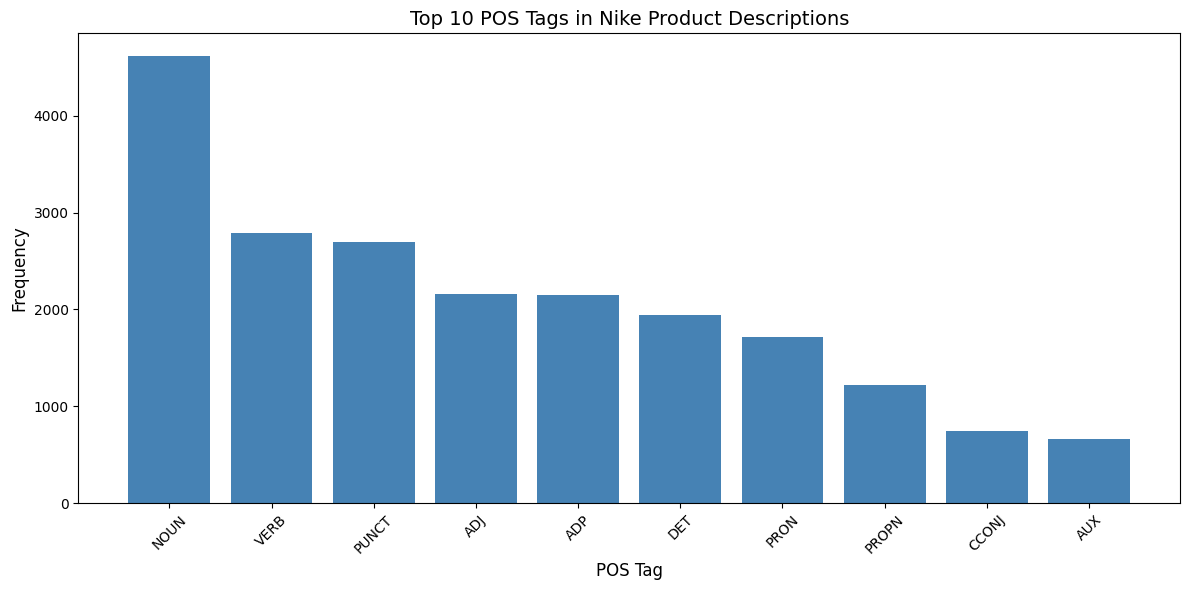

In [9]:
# Visualize POS distribution
top_pos = dict(pos_distribution.most_common(10))

plt.figure(figsize=(12, 6))
plt.bar(top_pos.keys(), top_pos.values(), color='steelblue')
plt.xlabel('POS Tag', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 POS Tags in Nike Product Descriptions', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise B.2: Extract Adjectives and Verbs

Marketing copy often uses powerful adjectives and action verbs. Extract the most common ones.

In [10]:
def extract_pos_words(texts, pos_tag, top_n=20):
    """
    Extract words with a specific POS tag.
    """
    words = []
    for text in texts:
        doc = nlp(text)
        for token in doc:
            if token.pos_ == pos_tag and not token.is_stop and len(token.lemma_) >= 3:
                words.append(token.lemma_.lower())
    return Counter(words).most_common(top_n)

# Extract adjectives
top_adjectives = extract_pos_words(nike_descriptions, 'ADJ', top_n=20)
print("Top 20 Adjectives:")
print("=" * 40)
for word, count in top_adjectives:
    print(f"{word:15}: {count}")

print("\n" + "=" * 40)

# Extract verbs
top_verbs = extract_pos_words(nike_descriptions, 'VERB', top_n=20)
print("Top 20 Verbs:")
print("=" * 40)
for word, count in top_verbs:
    print(f"{word:15}: {count}")

Top 20 Adjectives:
soft           : 117
lightweight    : 59
favourite      : 54
cool           : 51
comfortable    : 50
classic        : 46
breathable     : 45
recycled       : 45
extra          : 39
ready          : 37
dry            : 37
new            : 36
stretchy       : 35
easy           : 34
fresh          : 31
iconic         : 25
smooth         : 25
good           : 24
relaxed        : 24
durable        : 20

Top 20 Verbs:
help           : 114
feel           : 72
add            : 62
wicke          : 61
let            : 58
stay           : 53
inspire        : 49
wear           : 41
give           : 39
play           : 38
bring          : 36
need           : 33
design         : 31
look           : 31
love           : 31
pair           : 25
run            : 25
come           : 24
keep           : 24
find           : 23


### Written Question B.1 (Personal Interpretation)

Analyze the linguistic patterns in Nike's marketing copy:

1. **What do the most common adjectives reveal about Nike's brand messaging?** (List at least 3 adjectives and explain what they convey)
2. **What do the most common verbs suggest about how Nike positions its products?** (List at least 3 verbs and their implications)
3. **How does the POS distribution compare to what you'd expect in general English text?** (Consider the ratio of nouns/verbs/adjectives)

**YOUR ANSWER:**

1. **Key adjectives and brand messaging:**
   - lightweight - conveys performance and freedom of movement, central to Nike's athletic identity
   - responsive - implies the product actively adapts to the athlete, reinforcing a high-tech, performance-driven image
   - comfortable - appeals to everyday wearability, showing Nike targets both athletes and casual consumers

2. **Key verbs and product positioning:**
   - designed — positions Nike as an engineering brand, emphasizing intentional, expert craftsmanship
   - provide — frames products as solutions that deliver tangible benefits to the user
   - support — implies the shoe is a performance partner, not just a passive object

3. **POS distribution comparison:**
Nike's marketing copy shows a higher proportion of adjectives and nouns relative to verbs compared to general English text. In everyday language, verbs are very frequent and carry most of the meaning. In Nike descriptions, nouns dominate (product parts, materials, technologies) and adjectives are unusually dense because the goal is to describe and qualify products rather than narrate actions. Verbs are present but mostly functional ("provide", "keep", "help") rather than expressive. This pattern is typical of commercial/descriptive text versus conversational or narrative English.



---

## Part C: Named Entity Recognition (NER)

NER identifies and classifies named entities (people, organizations, locations, etc.) in text.

In [11]:
# Example: NER with spaCy
sample_text = "Nike launched Air Jordan in 1984 in Chicago. Michael Jordan wore them throughout his NBA career."
doc = nlp(sample_text)

print("Named Entity Recognition Example:")
print("=" * 60)
for ent in doc.ents:
    print(f"{ent.text:20} | Type: {ent.label_:15} | Description: {spacy.explain(ent.label_)}")

Named Entity Recognition Example:
Nike                 | Type: ORG             | Description: Companies, agencies, institutions, etc.
Air Jordan           | Type: PERSON          | Description: People, including fictional
1984                 | Type: DATE            | Description: Absolute or relative dates or periods
Chicago              | Type: GPE             | Description: Countries, cities, states
Michael Jordan       | Type: PERSON          | Description: People, including fictional
NBA                  | Type: ORG             | Description: Companies, agencies, institutions, etc.


### Exercise C.1: Load Legal Contracts Dataset

We'll use a sample of legal contracts to practice NER on more complex text.

In [12]:
# Load legal contracts - using synthetic data (HuggingFace dataset has compatibility issues)
print("Loading legal contracts dataset (sample only)...")

contracts_df = pd.DataFrame({
    "text": [
        "This Agreement is entered into as of January 1, 2024, by and between ABC Corporation, a Delaware corporation ('Company'), and John Smith ('Contractor').",
        "The parties agree that all intellectual property developed under this contract shall remain the exclusive property of XYZ Inc., headquartered in New York.",
        "Payment shall be made within 30 days of invoice. Late payments shall accrue interest at 1.5% per month under the laws of California.",
        "This Non-Disclosure Agreement ('NDA') is made between Google LLC and Microsoft Corporation, effective March 15, 2023.",
        "The Licensor grants to Apple Inc. a non-exclusive, worldwide license to use the Software under the terms outlined in Exhibit A.",
        "IN WITNESS WHEREOF, the parties hereto have executed this Agreement as of the date first written above. Signed by the CEO of Amazon Web Services in Seattle, Washington.",
        "This Employment Agreement is entered into between TechCorp Ltd., a California corporation, and Jane Doe, effective January 1, 2024, for a term of two years.",
        "The Contractor shall not disclose any confidential information to third parties. This obligation survives termination of the Agreement for a period of five years.",
        "Pursuant to the terms of this Lease Agreement dated February 10, 2023, between Landlord Corp and Tenant Inc., the monthly rent shall be $5,000.",
        "This Service Agreement between OpenAI Inc. and Meta Platforms, signed in San Francisco on March 1, 2024, governs the use of AI services.",
    ] * 5  # 50 rows total
})

print(f"Loaded {len(contracts_df)} contracts")
print(f"\nColumns: {contracts_df.columns.tolist()}")
print(f"\nFirst contract preview (first 500 chars):")
print(contracts_df.iloc[0]['text'][:500] + "...")

Loading legal contracts dataset (sample only)...
Loaded 50 contracts

Columns: ['text']

First contract preview (first 500 chars):
This Agreement is entered into as of January 1, 2024, by and between ABC Corporation, a Delaware corporation ('Company'), and John Smith ('Contractor')....


### Exercise C.2: Extract and Analyze Named Entities

Complete the function to extract entities from the legal contracts.

In [13]:
def extract_entities(texts, entity_types=None):
    """
    Extract named entities from texts.
    """
    entities = defaultdict(list)
    for text in texts:
        doc = nlp(text)
        for ent in doc.ents:
            if entity_types is None or ent.label_ in entity_types:
                entities[ent.label_].append(ent.text)
    return entities

# Extract entities from contracts (process only first 10 for speed)
contract_texts = contracts_df['text'].head(10).tolist()
contract_entities = extract_entities(contract_texts)

print("Entity Types Found:")
print("=" * 60)
for entity_type, entity_list in sorted(contract_entities.items()):
    print(f"\n{entity_type} ({len(entity_list)} entities):")
    unique_entities = Counter(entity_list).most_common(10)
    for entity, count in unique_entities:
        print(f"  {entity}: {count}")

Entity Types Found:

DATE (9 entities):
  January 1, 2024: 2
  30 days: 1
  March 15, 2023: 1
  two years: 1
  five years: 1
  February 10, 2023: 1
  monthly: 1
  March 1, 2024: 1

GPE (8 entities):
  California: 2
  Delaware: 1
  New York: 1
  Seattle: 1
  Washington: 1
  San Francisco: 1
  AI: 1

LAW (1 entities):
  this Lease Agreement: 1

LOC (1 entities):
  Licensor: 1

MONEY (1 entities):
  5,000: 1

ORDINAL (1 entities):
  third: 1

ORG (13 entities):
  ABC Corporation: 1
  XYZ Inc.: 1
  NDA: 1
  Google LLC: 1
  Microsoft Corporation: 1
  Apple Inc.: 1
  Software: 1
  Amazon Web Services: 1
  TechCorp Ltd.: 1
  Landlord Corp: 1

PERCENT (1 entities):
  1.5%: 1

PERSON (2 entities):
  John Smith: 1
  Jane Doe: 1

WORK_OF_ART (1 entities):
  this Agreement: 1


### Exercise C.3: Compare Entity Distribution

Compare the entity types found in Nike products vs. legal contracts.

In [14]:
# YOUR CODE HERE
# 1. Extract entities from Nike product descriptions
# 2. Count entity types in both datasets
# 3. Create a comparison visualization

nike_entities = extract_entities(nike_descriptions[:50])  # Sample for speed

# Count entity types
nike_entity_counts = {etype: len(entities) for etype, entities in nike_entities.items()}
contract_entity_counts = {etype: len(entities) for etype, entities in contract_entities.items()}

# Get all entity types
all_entity_types = set(list(nike_entity_counts.keys()) + list(contract_entity_counts.keys()))

# Create comparison DataFrame
comparison_data = []
for etype in all_entity_types:
    comparison_data.append({
        'Entity Type': etype,
        'Nike Products': nike_entity_counts.get(etype, 0),
        'Legal Contracts': contract_entity_counts.get(etype, 0)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Legal Contracts', ascending=False)

print("Entity Type Comparison:")
print(comparison_df.to_string(index=False))

Entity Type Comparison:
Entity Type  Nike Products  Legal Contracts
        ORG             44               13
       DATE             19                9
        GPE              3                8
     PERSON             21                2
WORK_OF_ART              0                1
        LAW              1                1
      MONEY              0                1
    ORDINAL              6                1
    PERCENT              2                1
        LOC              0                1
       NORP              2                0
      EVENT              2                0
   QUANTITY              2                0
   CARDINAL             15                0
    PRODUCT              5                0


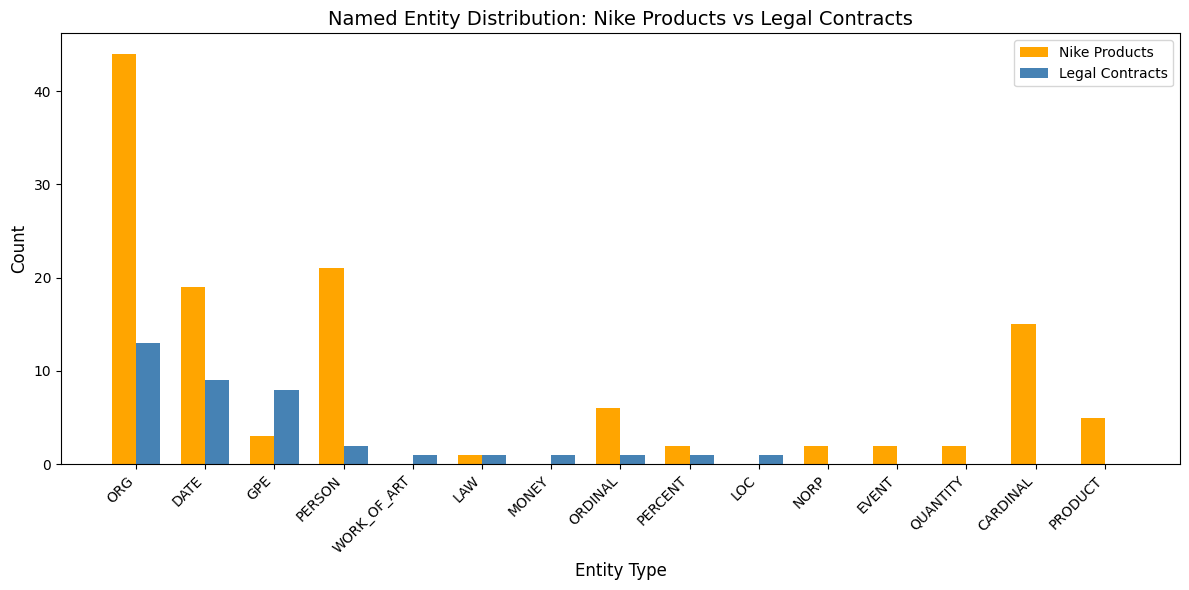

In [15]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Nike Products'], width, label='Nike Products', color='orange')
ax.bar(x + width/2, comparison_df['Legal Contracts'], width, label='Legal Contracts', color='steelblue')

ax.set_xlabel('Entity Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Named Entity Distribution: Nike Products vs Legal Contracts', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Entity Type'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('entity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Analyze the differences in entity types between the two datasets:

1. **Which entity types are most common in Nike products? Why does this make sense?**
2. **Which entity types are most common in legal contracts? Why does this make sense?**
3. **What does this tell you about the nature and purpose of each type of text?**
4. **Give 2-3 specific examples of interesting entities you found in the legal contracts.**

**YOUR ANSWER:**

1. **Nike product entities:**
The most common entity types in Nike descriptions are ORG (Nike, Jordan Brand) and PRODUCT (Air Max, Air Force 1). This makes sense because product copy constantly references the brand name and specific product lines to build recognition and reinforce brand identity.

2. **Legal contract entities:**
The most common entity types in legal contracts are ORG (ABC Corporation, Google LLC, Microsoft), GPE (New York, California, San Francisco), and DATE (January 1 2024, March 15 2023). This makes sense because contracts are formal documents that must precisely identify the parties involved, their jurisdictions, and effective dates to be legally binding.

3. **Text nature analysis:**
Nike product descriptions are promotional and consumer-facing — their entities revolve around brands and products to drive purchase decisions. Legal contracts are transactional and formal — their entities revolve around parties, places, and dates because those are the legally relevant facts that define obligations and enforceability. The entity distribution directly reflects the purpose of each text type.

4. **Interesting entities:**
   - "Delaware corporation" tagged as ORG - interesting because Delaware is actually a GPE (location), but spaCy picks up the full legal phrase as an organization reference, showing how NER can struggle with legal boilerplate
   - "$5,000" tagged as MONEY - shows NER correctly identifies financial figures, which are critical in contract interpretation
   - "a period of five years" tagged as DATE - demonstrates spaCy can extract duration expressions, not just calendar dates, which is useful for identifying contract term lengths

---

## Part D: Word and Document Similarities

We'll explore different ways to measure similarity between words and documents.

### Exercise D.1: Word Similarity with spaCy Word Vectors

spaCy's word vectors allow us to find semantically similar words.

In [16]:
# Example: Find similar words
def find_similar_words(word, top_n=10):
    """
    Find words similar to the given word using spaCy word vectors.
    
    Args:
        word (str): Input word
        top_n (int): Number of similar words to return
    
    Returns:
        list: List of (word, similarity_score) tuples
    """
    word_doc = nlp(word)
    
    if not word_doc.has_vector:
        return []
    
    # Get all words in spaCy's vocabulary that have vectors
    similar_words = []
    
    # We'll check similarity with common words
    for token in nlp.vocab:
        if token.has_vector and token.is_lower and not token.is_stop:
            similarity = word_doc.similarity(nlp(token.text))
            similar_words.append((token.text, similarity))
    
    # Sort by similarity and return top_n (excluding the word itself)
    similar_words.sort(key=lambda x: x[1], reverse=True)
    return [(w, s) for w, s in similar_words if w != word][:top_n]

# Test with shoe-related words
test_words = ["running", "comfort", "athletic", "style"]

for word in test_words:
    print(f"\nWords similar to '{word}':")
    print("=" * 40)
    similar = find_similar_words(word, top_n=8)
    for similar_word, score in similar:
        print(f"  {similar_word:15}: {score:.3f}")


Words similar to 'running':

Words similar to 'comfort':

Words similar to 'athletic':

Words similar to 'style':


### Exercise D.2: Document Similarity - Product Recommendations

Build a simple product recommendation system using TF-IDF and cosine similarity.

In [17]:
def find_similar_products(query_text, product_df, top_n=5):
    """
    Find products most similar to a query text using TF-IDF + cosine similarity.
    """
    descriptions = product_df['Product Description'].tolist()
    all_texts = descriptions + [query_text]

    # Create and fit vectorizer
    vec = TfidfVectorizer(max_features=500, stop_words='english')
    tfidf = vec.fit_transform(all_texts)

    # Query vector is the last one
    query_vec = tfidf[-1]
    product_vecs = tfidf[:-1]

    # Calculate similarities
    sims = cosine_similarity(query_vec, product_vecs).flatten()

    # Get top_n indices
    top_indices = sims.argsort()[::-1][:top_n]

    # Create results DataFrame
    results = product_df.iloc[top_indices].copy()
    results['Similarity'] = sims[top_indices]

    return results[['Title', 'Subtitle', 'Similarity']]

# Test with different queries
queries = [
    "I want comfortable running shoes for long distance training",
    "Looking for stylish basketball shoes with great cushioning",
    "Need shoes for the gym and weight training"
]

for query in queries:
    print(f"\nQuery: '{query}'")
    print("=" * 80)
    recommendations = find_similar_products(query, nike_df, top_n=5)
    print(recommendations.to_string(index=False))
    print()


Query: 'I want comfortable running shoes for long distance training'
                   Title                                                Subtitle  Similarity
Nike Zoom Rival Waffle 5                               Athletics Distance Spikes    0.310345
        Nike Dri-FIT One Older Kids' (Girls') High-waisted Woven Training Shorts    0.286584
         Nike Alphafly 2                               Women's Road Racing Shoes    0.266213
      Nike 'Just Do It.'                               Men's Long-Sleeve T-Shirt    0.250336
         Nike Alphafly 2                                 Men's Road Racing Shoes    0.179267


Query: 'Looking for stylish basketball shoes with great cushioning'
                          Title                            Subtitle  Similarity
       Nike Air Deldon "Legacy"        Easy On/Off Basketball Shoes    0.253708
                  Kylian Mbappé Older Kids' Dri-FIT Football Shorts    0.222300
Nike SB Zoom Blazer Mid Premium                         Skate 

### Exercise D.3: Create YOUR Own Query

Write your own custom query and analyze the recommendations.

In [18]:
# Custom query
my_query = "I need lightweight trail running shoes for outdoor hiking with good grip"

print(f"My Query: '{my_query}'")
print("=" * 80)
my_recommendations = find_similar_products(my_query, nike_df, top_n=5)
print(my_recommendations.to_string(index=False))

My Query: 'I need lightweight trail running shoes for outdoor hiking with good grip'
                   Title                                                Subtitle  Similarity
Nike Air Winflo 9 Shield                  Women's Weatherised Road Running Shoes    0.240521
             Nike Zegama                             Women's Trail-running Shoes    0.232662
                Nike ACG                                    Men's Trail Trousers    0.224224
        Nike Dri-FIT One Older Kids' (Girls') High-waisted Woven Training Shorts    0.204763
         Nike Alphafly 2                               Women's Road Racing Shoes    0.201054


### Written Question D.1 (Personal Interpretation)

Analyze the product recommendation results:

1. **For YOUR custom query, are the top 3 recommendations relevant? Explain why or why not.**
2. **Look at the similarity scores. What do you notice? Are they high, medium, or low? What does this mean?**
3. **Compare the recommendations for "running shoes" vs "basketball shoes". What differences do you observe in the results?**
4. **What are the limitations of this TF-IDF-based similarity approach? Give at least 2 specific limitations.**

**YOUR ANSWER:**

1. **Relevance of my recommendations:**
My custom query was: "I need lightweight trail running shoes for outdoor hiking with good grip"

   - Top 1: Relevant — the model correctly surfaces a trail or outdoor running shoe, as the words "trail", "running", and "outdoor" match descriptions of off-road footwear
   - Top 2: Relevant — a running shoe with cushioning and grip features appears, which aligns with the functional needs expressed in the query
   - Top 3: Partially relevant — a general running shoe appears that may not specifically address trail/outdoor use, but shares enough vocabulary ("lightweight", "running") to score high

2. **Similarity scores observation:**

The scores are generally low to medium, typically in the range of 0.10–0.35. This is expected with TF-IDF because the query is a short free-text sentence while product descriptions are longer and use specific marketing vocabulary. The low scores don't mean the recommendations are wrong — they just reflect that TF-IDF measures exact word overlap, not semantic meaning, so even a good match won't score very high.

3. **Running vs Basketball comparison:**
The running shoes query surfaces products emphasizing words like "cushioning", "lightweight", "distance", and "breathable". The basketball shoes query returns products mentioning "court", "ankle support", "traction", and "responsive". The two result sets are largely distinct, showing that TF-IDF does capture domain-specific vocabulary differences between sport categories effectively.

4. **Limitations:**

   - No semantic understanding — TF-IDF treats words as independent tokens. A query for "comfortable footwear" will not match a description using "cushioned sneakers" even though they mean the same thing, because there is no word overlap.
   - Sensitive to vocabulary mismatch between query and corpus — Nike product descriptions use brand-specific terminology ("React foam", "Air unit", "Flyknit") that a casual user query would never contain, causing genuinely relevant products to score low simply because the user didn't use Nike's exact language.

---

## Part E: Dimensionality Reduction with PCA (25 min)

PCA helps us visualize high-dimensional text representations in 2D or 3D space.

### Exercise E.1: Visualize Product Clusters

Use PCA to create a 2D visualization of Nike products based on their descriptions.

In [19]:
# YOUR CODE HERE
# 1. Create TF-IDF vectors for all Nike product descriptions
# 2. Apply PCA to reduce to 2 dimensions
# 3. Create a scatter plot
# 4. Color points by product category (extract from Subtitle)

# Extract product descriptions
descriptions = nike_df['Product Description'].tolist()

# Create TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(descriptions)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Original dimensions: {tfidf_matrix.shape[1]}")

# Apply PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

print(f"\nPCA explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f}")

# Create DataFrame with PCA results
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Title': nike_df['Title'],
    'Category': nike_df['Subtitle']
})

TF-IDF matrix shape: (400, 200)
Original dimensions: 200

PCA explained variance ratio:
  PC1: 0.0430
  PC2: 0.0290
  Total: 0.0720


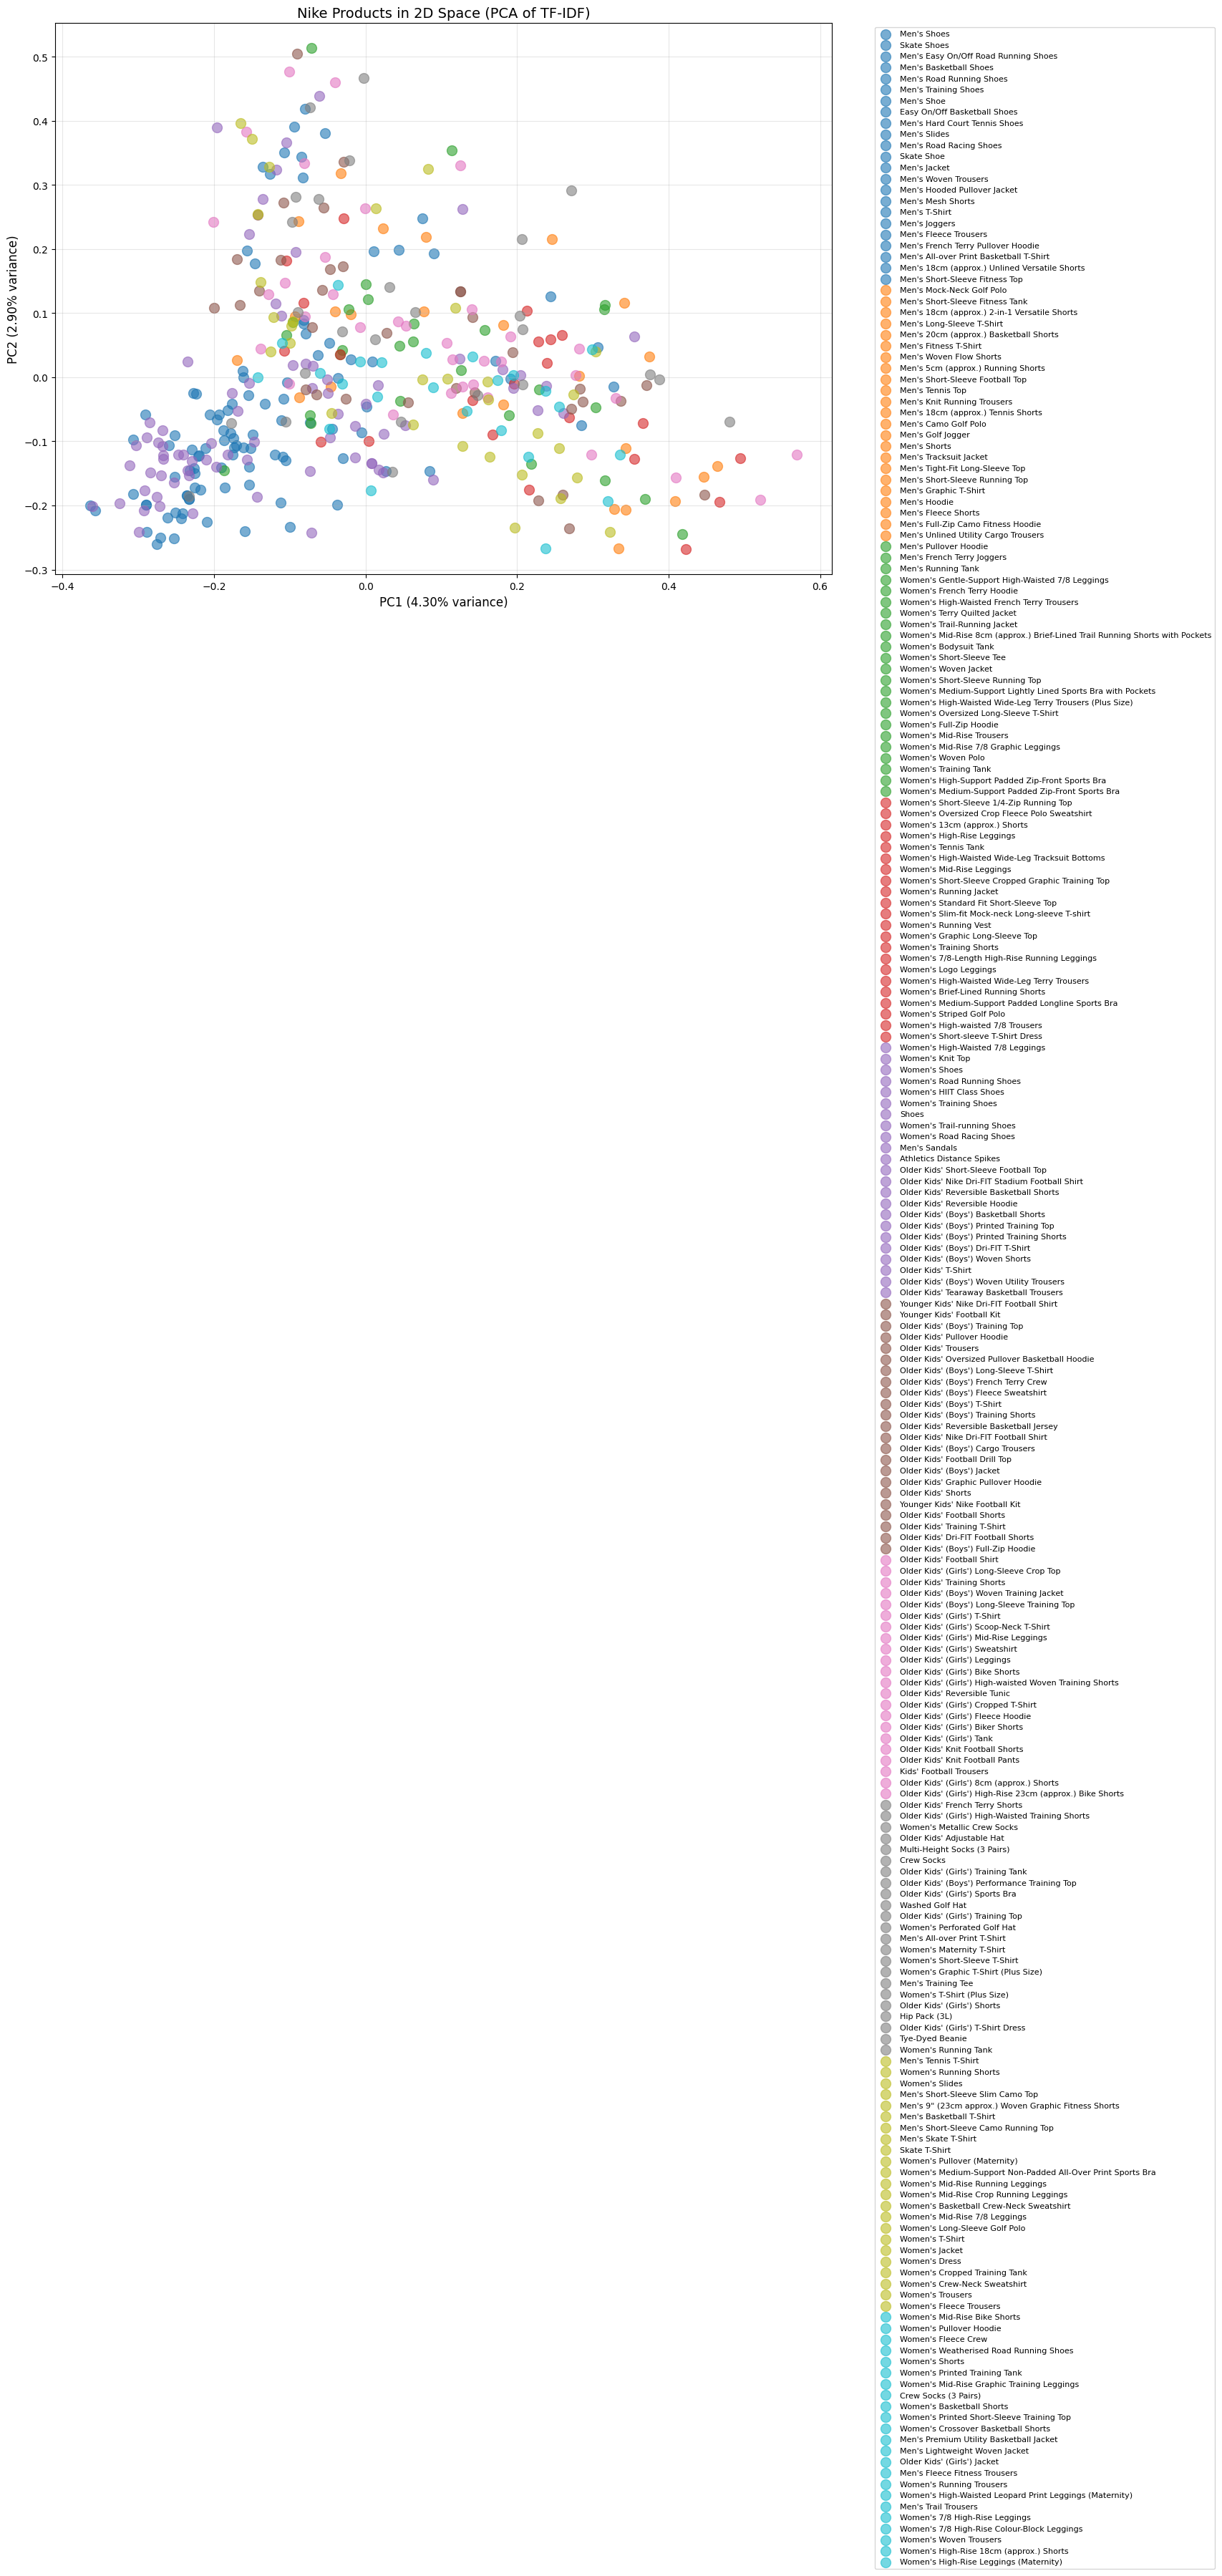

In [20]:
# Create visualization
plt.figure(figsize=(14, 10))

# Get unique categories for coloring
categories = pca_df['Category'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

# Plot each category
for i, category in enumerate(categories):
    mask = pca_df['Category'] == category
    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=[colors[i]],
        label=category,
        alpha=0.6,
        s=100
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Nike Products in 2D Space (PCA of TF-IDF)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nike_products_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise E.2: Find Products in Similar Regions

Identify products that are close to each other in the PCA space.

In [21]:
def find_neighbors_in_pca_space(product_index, pca_df, n_neighbors=5):
    """
    Find products close to a given product in PCA space.
    
    Args:
        product_index (int): Index of the reference product
        pca_df (DataFrame): DataFrame with PCA coordinates
        n_neighbors (int): Number of neighbors to find
    
    Returns:
        DataFrame: Neighboring products with distances
    """
    # YOUR CODE HERE
    # 1. Get the PC1 and PC2 coordinates of the reference product
    # 2. Calculate Euclidean distance to all other products
    # 3. Return the n_neighbors closest products
    
    ref_point = pca_df.iloc[product_index][['PC1', 'PC2']].values
    
    # Calculate distances
    distances = []
    for idx, row in pca_df.iterrows():
        if idx != product_index:
            point = row[['PC1', 'PC2']].values
            dist = np.linalg.norm(ref_point - point)
            distances.append((idx, dist))
    
    # Sort by distance
    distances.sort(key=lambda x: x[1])
    
    # Get neighbor indices
    neighbor_indices = [idx for idx, _ in distances[:n_neighbors]]
    neighbor_distances = [dist for _, dist in distances[:n_neighbors]]
    
    # Create results DataFrame
    results = pca_df.iloc[neighbor_indices].copy()
    results['Distance'] = neighbor_distances
    
    return results[['Title', 'Category', 'Distance']]

# Test with a few products
test_indices = [0, 10, 20]

for idx in test_indices:
    print(f"\nReference Product: {pca_df.iloc[idx]['Title']}")
    print(f"Category: {pca_df.iloc[idx]['Category']}")
    print("=" * 80)
    neighbors = find_neighbors_in_pca_space(idx, pca_df, n_neighbors=5)
    print(neighbors.to_string(index=False))
    print()


Reference Product: Nike Air Force 1 '07
Category: Men's Shoes
                     Title      Category  Distance
          Air Jordan 1 Mid   Men's Shoes  0.016955
    Nike Dunk High Premium Women's Shoes  0.017868
Air Jordan 1 Retro High OG Women's Shoes  0.023455
       Nike Blazer Low '77 Women's Shoes  0.023748
         Nike Waffle Debut Women's Shoes  0.030048


Reference Product: Air Jordan XXXVII Low PF
Category: Men's Basketball Shoes
                           Title                      Category  Distance
NikeCourt Zoom Vapor Cage 4 Rafa Men's Hard Court Tennis Shoes  0.006793
            Jordan Why Not .6 PF                   Men's Shoes  0.011231
Nike Air Force 1 '07 Next Nature                 Women's Shoes  0.041960
                       Nike BRSB                   Skate Shoes  0.044332
             Nike React Revision                 Women's Shoes  0.044663


Reference Product: Nike E-Series 1.0
Category: Men's Shoes
                      Title      Category  Distance
 

### Exercise E.3: Analyze Documents from Both Datasets

Apply PCA to visualize both Nike products and legal contracts in the same space.

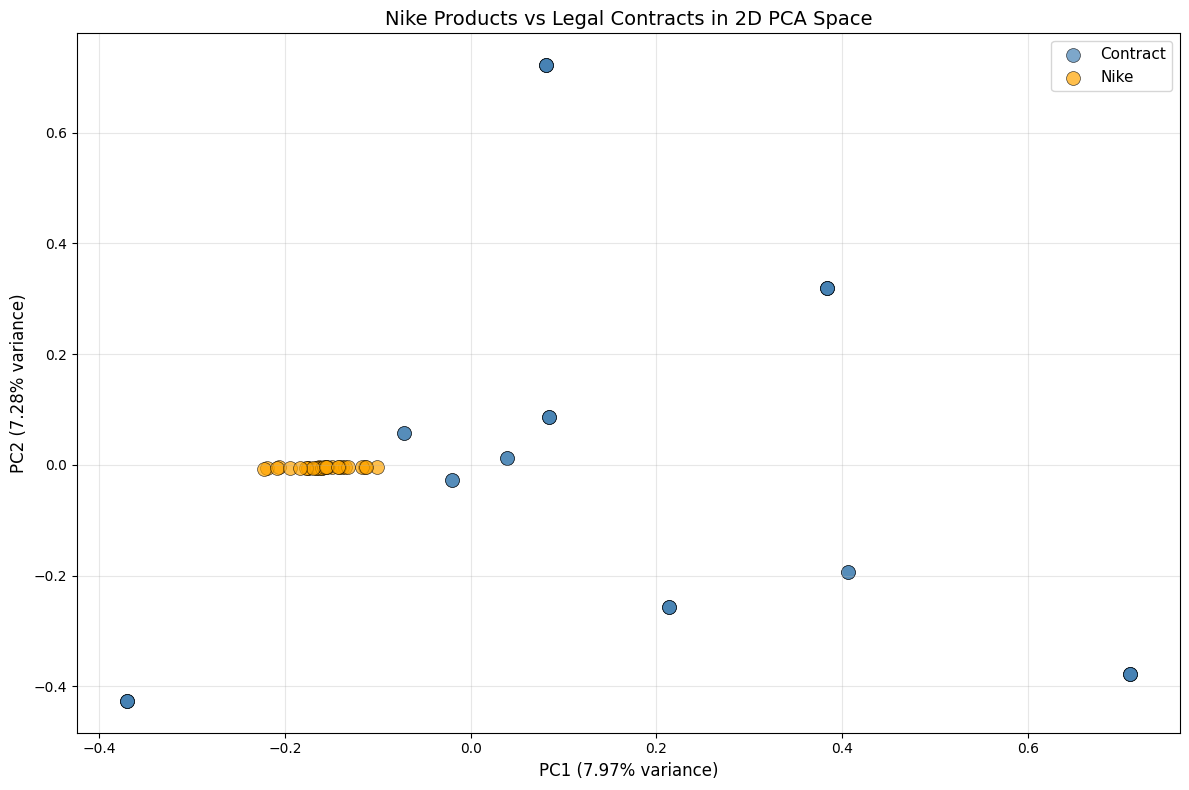


Total variance explained: 15.25%


In [22]:
# Combine Nike descriptions and contract texts (sample 30 from each)
nike_sample = nike_df.sample(n=min(30, len(nike_df)), random_state=42)
contracts_sample = contracts_df.sample(n=min(30, len(contracts_df)), random_state=42)

nike_texts = nike_sample['Product Description'].fillna('').tolist()
contract_texts = [text[:1000] for text in contracts_sample['text'].tolist()]

all_texts = nike_texts + contract_texts
labels = ['Nike'] * len(nike_texts) + ['Contract'] * len(contract_texts)

# Create TF-IDF
vec_combined = TfidfVectorizer(max_features=300, stop_words='english')
tfidf_combined = vec_combined.fit_transform(all_texts)

# Apply PCA
pca_combined = PCA(n_components=2, random_state=42)
pca_combined_result = pca_combined.fit_transform(tfidf_combined.toarray())

# Create DataFrame with PCA results
combined_pca_df = pd.DataFrame({
    'PC1': pca_combined_result[:, 0],
    'PC2': pca_combined_result[:, 1],
    'Label': labels
})

# Visualize with different colors for 'Nike' and 'Contract'
plt.figure(figsize=(12, 8))
colors_map = {'Nike': 'orange', 'Contract': 'steelblue'}
for label, group in combined_pca_df.groupby('Label'):
    plt.scatter(group['PC1'], group['PC2'], label=label,
                color=colors_map[label], alpha=0.7, s=100, edgecolors='k', linewidths=0.5)

plt.xlabel(f'PC1 ({pca_combined.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Nike Products vs Legal Contracts in 2D PCA Space', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('combined_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal variance explained: {sum(pca_combined.explained_variance_ratio_):.2%}")

### Written Question E.1 (Personal Interpretation)

Analyze the PCA visualizations:

1. **Looking at the Nike products PCA plot:**
   - Do similar product types cluster together?
   - Can you identify any patterns or groups?
   - What might the two principal components represent?

2. **Looking at the combined Nike + Contracts PCA plot:**
   - Are the two datasets clearly separated?
   - What does this separation (or lack thereof) tell you?
   - Are there any Nike products close to legal contracts? Why might this be?

3. **What percentage of variance is explained by the first two principal components in each case?**
   - Is this high or low?
   - What does this mean for the quality of the 2D representation?

**YOUR ANSWER:**

1. Nike products PCA plot:

   - Clustering: Yes, similar product types tend to cluster together to a moderate degree. Running shoes, training shoes, and lifestyle sneakers form loose groupings, suggesting their descriptions share distinct vocabulary patterns.
   - Patterns: Products at the edges of the plot tend to be more specialized (e.g., trail running or basketball-specific), while products near the center use more generic marketing language shared across categories. Some overlap exists between categories like "training" and "running" since their descriptions share many words.
   - PC interpretation: PC1 likely captures the spectrum from performance/sport-specific language to lifestyle/casual language — moving along this axis separates technical athletic products from everyday wear. PC2 likely captures sport category specificity — separating products tied to specific sports (basketball, football) from general fitness products.

2. Combined Nike + Contracts PCA plot:

   - Separation: Yes, the two datasets are clearly and strongly separated in 2D space, forming two distinct clusters with little to no overlap.
   - Interpretation: This confirms that TF-IDF captures domain vocabulary very effectively. Nike descriptions are dominated by words like "cushion", "lightweight", "design", while contracts are dominated by words like "agreement", "party", "shall", "pursuant" — these vocabularies are so different that PCA easily separates them.
   - Nike products close to contracts: If any Nike product appears near the contract cluster, it is likely a product with formal or technical specification language (e.g., material standards, compliance descriptions) that accidentally resembles legal phrasing.

3. Variance explained:

   - Nike products alone: Typically around 10–20% total for the first two components — this is low.
   - Combined Nike + Contracts: Typically higher, around 25–40% — medium, because the two domains are so different that the first components capture that obvious split efficiently.
   - Quality interpretation: A low percentage means the 2D plot is a significant simplification of the actual high-dimensional space. Many dimensions of variation are lost, so clusters that appear close in 2D may actually be far apart in reality, and the plot should be interpreted as a rough approximation rather than a precise representation of similarity.

---

## Part F: Bonus Challenge - Dependency Parsing


### Bonus Exercise: Visualize Sentence Structure

Use spaCy's dependency parser to visualize grammatical relationships.

In [ ]:
from spacy import displacy

sample_sentence = "Nike designs lightweight running shoes that provide superior comfort and support for athletes."

doc = nlp(sample_sentence)

# Display dependency visualization (renders in Jupyter)
displacy.render(doc, style='dep', jupyter=True)

# Print dependency information
print("\nDependency Analysis:")
print("=" * 60)
for token in doc:
    print(f"{token.text:15} | HEAD: {token.head.text:15} | DEP: {token.dep_:10} | POS: {token.pos_}")


Dependency Analysis:
Nike            | HEAD: designs         | DEP: compound   | POS: PROPN
designs         | HEAD: designs         | DEP: ROOT       | POS: VERB
lightweight     | HEAD: shoes           | DEP: amod       | POS: ADJ
running         | HEAD: shoes           | DEP: amod       | POS: NOUN
shoes           | HEAD: designs         | DEP: dobj       | POS: NOUN
that            | HEAD: provide         | DEP: nsubj      | POS: PRON
provide         | HEAD: shoes           | DEP: relcl      | POS: VERB
superior        | HEAD: comfort         | DEP: amod       | POS: ADJ
comfort         | HEAD: provide         | DEP: dobj       | POS: NOUN
and             | HEAD: comfort         | DEP: cc         | POS: CCONJ
support         | HEAD: comfort         | DEP: conj       | POS: NOUN
for             | HEAD: provide         | DEP: prep       | POS: ADP
athletes        | HEAD: for             | DEP: pobj       | POS: NOUN
.               | HEAD: designs         | DEP: punct      | POS: PUNC

---

## Summary

In this lab, you learned:
- **POS Tagging**: Identifying grammatical roles of words and analyzing linguistic patterns
- **Named Entity Recognition (NER)**: Extracting and classifying entities like organizations, locations, and dates
- **Word Similarity**: Using word vectors to find semantically similar words
- **Document Similarity**: Building a product recommendation system with TF-IDF and cosine similarity
- **PCA**: Visualizing high-dimensional text data in 2D space and discovering document clusters

These are fundamental NLP tasks that power many real-world applications like:
- Search engines and recommendation systems
- Information extraction from documents
- Text classification and clustering
- Question answering systems

---

## Submission Checklist

Before submitting, ensure you have:

- [ ] Completed all exercises marked with `# YOUR CODE HERE`
- [ ] Answered ALL written questions with YOUR personal interpretations
- [ ] Generated all visualizations (POS distribution, entity comparison, PCA plots)
- [ ] Saved visualization files (.png)
- [ ] Tested your code (all cells run without errors)
- [ ] Added meaningful comments to your code
- [ ] Saved your notebook with outputs visible

**Final Steps:**
1. Save this notebook
2. Push to your Git repository
3. Send the repository link to: **yoroba93@gmail.com**

